In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

In [2]:
# --- Load the cleaned and transformed dataset ---
df = pd.read_csv("cleaned_data_transformed.csv")
df.head()

,realSum,logSum,room_type_apt,room_type_private,room_type_shared,person_capacity,is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,city,is_weekday
0,194.033698,5.268032,0,1,0,2.0,0,1,0,10.0,93.0,1,5.022964,2.539380,78.690379,4.166708,98.253896,6.846473,1,1
1,344.245776,5.841356,0,1,0,4.0,0,0,0,8.0,85.0,1,0.488389,0.239404,631.176378,33.421209,837.280757,58.342928,1,1
2,264.101422,5.576333,0,1,0,2.0,0,0,1,9.0,87.0,1,5.748312,3.651621,75.275877,3.985908,95.386955,6.646700,1,1
3,433.529398,6.071960,0,1,0,4.0,0,0,1,9.0,90.0,2,0.384862,0.439876,493.272534,26.119108,875.033098,60.973565,1,1
4,485.552926,6.185288,0,1,0,2.0,1,0,0,10.0,98.0,1,0.544738,0.318693,552.830324,29.272733,815.305740,56.811677,1,1


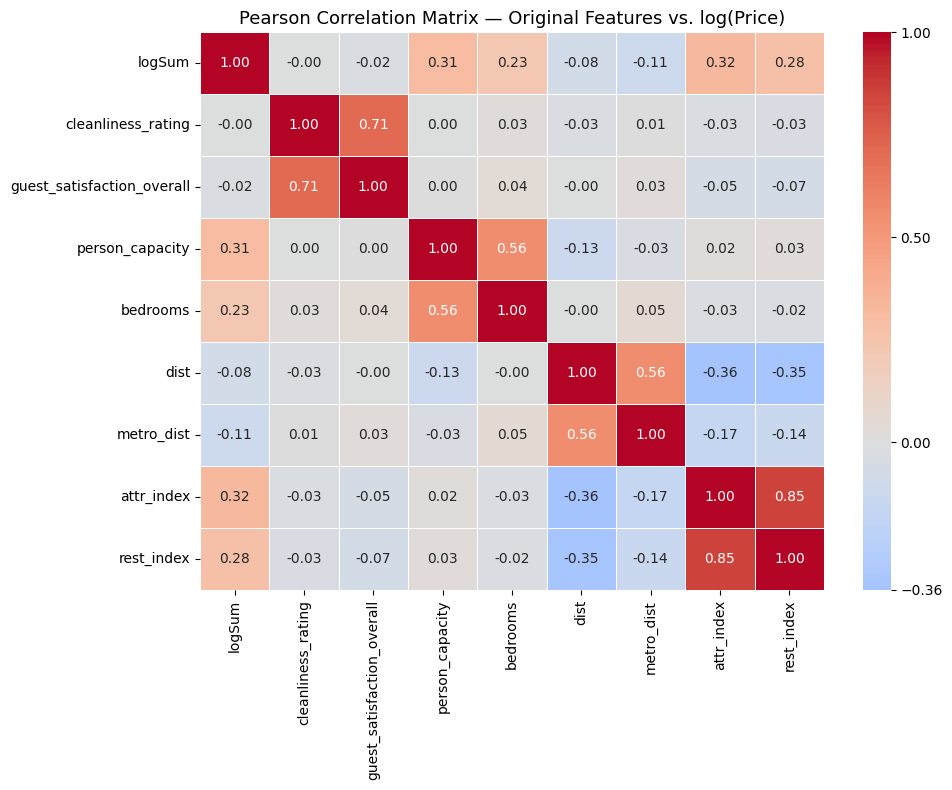

In [3]:
# --- Correlation Matrix: Original Features ---

numeric_cols = [
    "logSum",
    "cleanliness_rating",
    "guest_satisfaction_overall",
    "person_capacity", 
    "bedrooms", 
    "dist", 
    "metro_dist",
    "attr_index", 
    "rest_index"]

corr_matrix_orig = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix_orig,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"ticks": [1.0, 0.5, 0.0, -0.36]},
)
ax.set_title("Pearson Correlation Matrix — Original Features vs. log(Price)", fontsize=13)
plt.tight_layout()
plt.savefig("correlation_matrix_original.png", dpi=300, bbox_inches="tight")
plt.show()


In [4]:
# --- PCA Composite for Satisfaction ---
# Motivation: the Naive OLS showed VIF ~195–207 for cleanliness_rating and
# guest_satisfaction_overall, and the Omitted OLS showed dropping them hurts fit.
# Solution: replace both with orthogonal PCA scores that retain all variance (VIF ≈ 1).

rating_cols = ["cleanliness_rating", "guest_satisfaction_overall"]
scaler = StandardScaler()
ratings_scaled = scaler.fit_transform(df[rating_cols])

pca_sat = PCA(n_components=2, random_state=42)
pc_scores = pca_sat.fit_transform(ratings_scaled)

print("Explained variance ratio per component:")
for i, evr in enumerate(pca_sat.explained_variance_ratio_, 1):
    print(f"  PC{i}: {evr:.3f}")
print(f"  Total: {pca_sat.explained_variance_ratio_.sum():.3f}")

print("\nLoadings:")
for i, comp in enumerate(pca_sat.components_, 1):
    print(f"  PC{i} — cleanliness_rating: {comp[0]:.3f}, "
          f"guest_satisfaction_overall: {comp[1]:.3f}")


Explained variance ratio per component:
  PC1: 0.856
  PC2: 0.144
  Total: 1.000

Loadings:
  PC1 — cleanliness_rating: 0.707, guest_satisfaction_overall: 0.707
  PC2 — cleanliness_rating: -0.707, guest_satisfaction_overall: 0.707


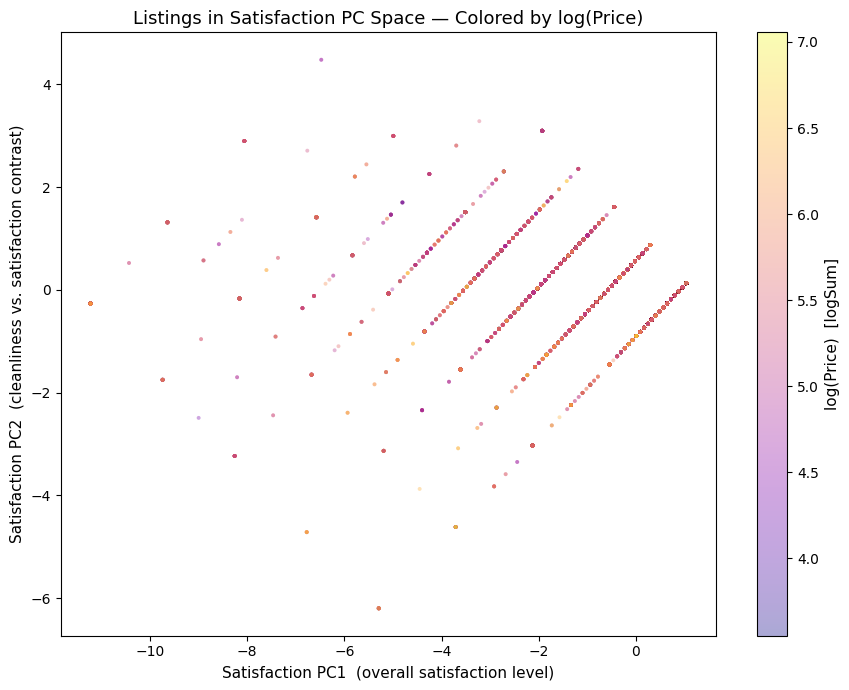

In [6]:
# --- Interpretation of PC Space: colored by log(Price) ---
fig, ax = plt.subplots(figsize=(9, 7))

sc = ax.scatter(
    pc_scores[:, 0],
    pc_scores[:, 1],
    c=df["logSum"],
    cmap="plasma",
    alpha=0.35,
    s=8,
    linewidths=0,
)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("log(Price)  [logSum]", fontsize=11)

ax.set_xlabel("Satisfaction PC1  (overall satisfaction level)", fontsize=11)
ax.set_ylabel("Satisfaction PC2  (cleanliness vs. satisfaction contrast)", fontsize=11)
ax.set_title("Listings in Satisfaction PC Space — Colored by log(Price)", fontsize=13)

plt.tight_layout()
plt.savefig("pca_scatter_logprice.png", dpi=300, bbox_inches="tight")
plt.show()


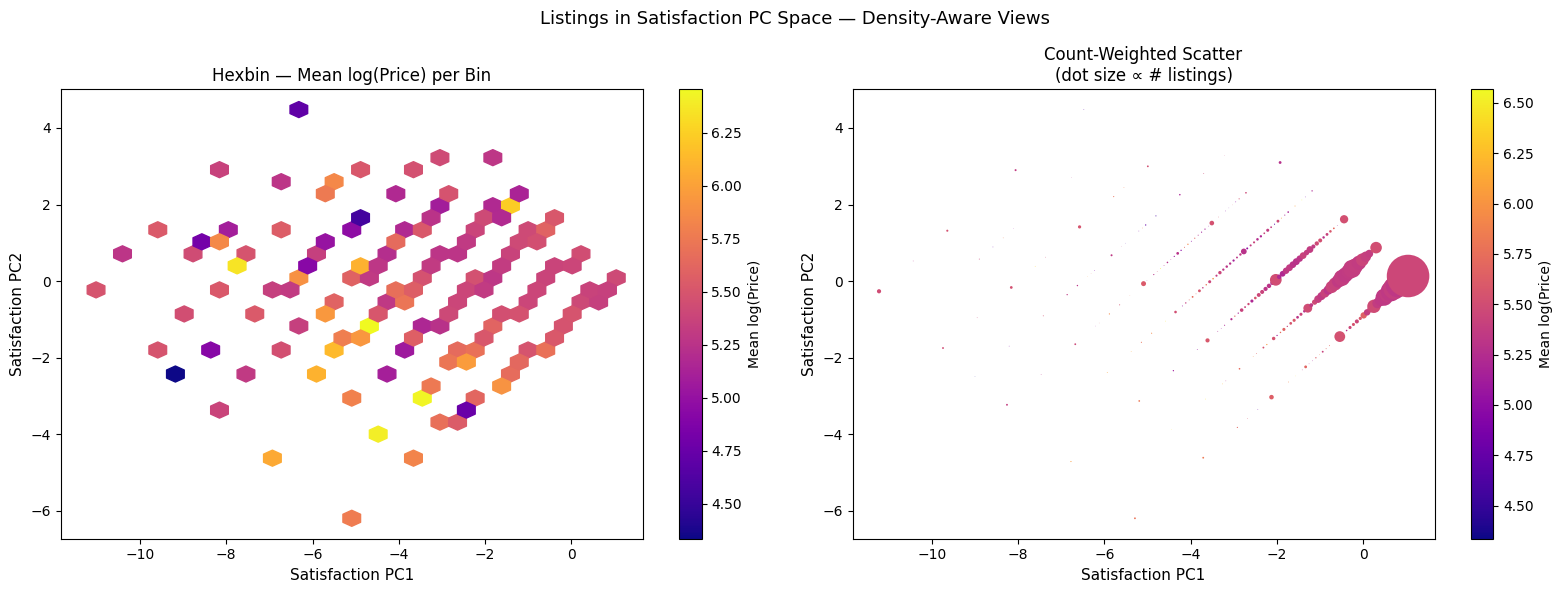

Unique (PC1, PC2) grid positions: 234
Total listings: 51189


In [7]:
# --- Density-aware views of PC space ---

_pc_df = pd.DataFrame({
    "satisfaction_pc1": pc_scores[:, 0],
    "satisfaction_pc2": pc_scores[:, 1],
    "logSum": df["logSum"].values,
})

counts = (
    _pc_df.groupby(["satisfaction_pc1", "satisfaction_pc2"])["logSum"]
    .agg(n="count", mean_logprice="mean")
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Option 1: hexbin ---
hb = axes[0].hexbin(
    pc_scores[:, 0],
    pc_scores[:, 1],
    C=df["logSum"],
    gridsize=30,
    cmap="plasma",
    reduce_C_function=np.mean,
)
fig.colorbar(hb, ax=axes[0]).set_label("Mean log(Price)", fontsize=10)
axes[0].set_xlabel("Satisfaction PC1", fontsize=11)
axes[0].set_ylabel("Satisfaction PC2", fontsize=11)
axes[0].set_title("Hexbin — Mean log(Price) per Bin", fontsize=12)

# --- Option 2: count-weighted scatter ---
sc2 = axes[1].scatter(
    counts["satisfaction_pc1"],
    counts["satisfaction_pc2"],
    s=counts["n"] / 10,
    c=counts["mean_logprice"],
    cmap="plasma",
    alpha=1.0,
    linewidths=0,
)
fig.colorbar(sc2, ax=axes[1]).set_label("Mean log(Price)", fontsize=10)
axes[1].set_xlabel("Satisfaction PC1", fontsize=11)
axes[1].set_ylabel("Satisfaction PC2", fontsize=11)
axes[1].set_title("Count-Weighted Scatter\n(dot size ∝ # listings)", fontsize=12)

plt.suptitle("Listings in Satisfaction PC Space — Density-Aware Views", fontsize=13)
plt.tight_layout()
plt.savefig("pca_scatter_density.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Unique (PC1, PC2) grid positions: {len(counts)}")
print(f"Total listings: {counts['n'].sum()}")


In [ ]:
# --- Full-feature PCA ---
# All continuous numeric predictors; excludes targets (realSum, logSum),
# binary/categorical cols, and the satisfaction PCs already derived above.
# All components computed; projection onto top 2 is used in the scatter below.

all_numeric_cols = [
    "person_capacity",
    "cleanliness_rating", "guest_satisfaction_overall",
    "bedrooms", "dist", "metro_dist",
    "attr_index", "attr_index_norm",
    "rest_index", "rest_index_norm",
]

scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(df[all_numeric_cols])

pca_full = PCA(n_components=len(all_numeric_cols), random_state=42)
pc_full = pca_full.fit_transform(X_full_scaled)

print("Explained variance ratio per component:")
cumulative = 0.0
for i, evr in enumerate(pca_full.explained_variance_ratio_, 1):
    cumulative += evr
    print(f"  PC{i:02d}: {evr:.3f}  (cumulative: {cumulative:.3f})")

print("\nLoadings (rows = features, cols = PCs):")
loading_df = pd.DataFrame(
    pca_full.components_.T,
    index=all_numeric_cols,
    columns=[f"PC{i}" for i in range(1, len(all_numeric_cols) + 1)],
)
print(loading_df.round(3).to_string())


In [ ]:
# --- Scatter: all listings in full-feature PC space, colored by log(Price) ---
fig, ax = plt.subplots(figsize=(9, 7))

sc_full = ax.scatter(
    pc_full[:, 0],
    pc_full[:, 1],
    c=df["logSum"],
    cmap="plasma",
    alpha=0.2,
    s=5,
    linewidths=0,
)

cbar = fig.colorbar(sc_full, ax=ax)
cbar.set_label("log(Price)  [logSum]", fontsize=11)

ax.set_xlabel(f"PC1  ({pca_full.explained_variance_ratio_[0]:.1%} variance)", fontsize=11)
ax.set_ylabel(f"PC2  ({pca_full.explained_variance_ratio_[1]:.1%} variance)", fontsize=11)
ax.set_title("All Listings in Full-Feature PC Space — Colored by log(Price)", fontsize=13)

plt.tight_layout()
plt.savefig("pca_full_scatter_logprice.png", dpi=300, bbox_inches="tight")
plt.show()
